In [1]:

import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate

from autotsc import utils

In [2]:
rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()
v = rdf.group_by("model").agg(pl.len()).sort("len", descending=True).collect()
for row in v.iter_rows(named=True):
    print(f"{row['model']}: {row['len']}")

/tmp/ipykernel_2156636/2562833565.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()


downsample-mr-hydra: 640
catch22: 640
quant: 640
stacker-v4-r1: 640
drcif: 640
rdst: 640
polar-magnitude-mr-hydra: 640
cumsum-mr-hydra: 640
polar-angle-mr-hydra: 640
rstsf: 640
scale-mr-hydra: 640
u-rstsf: 640
mr-hydra: 640
rank-mr-hydra: 640
difference-mr-hydra: 640
hivecotev2: 465
fast-stacker-v4-r1: 136
fast-stacker-v5-r1: 81
fast-stacker-v5-r3: 39
stacker-v4-r3: 23


In [3]:
df = (
    rdf
    .filter(pl.col("model") != "stacker-v4-r3")
    .filter(pl.col("model") != "difference-mr-hydra")
    .filter(pl.col("model") != "scale-mr-hydra")
    .filter(pl.col("model") != "cumsum-mr-hydra")
    .filter(pl.col("model") != "downsample-mr-hydra")
    .filter(pl.col("model") != "rank-mr-hydra")
    .filter(pl.col("model") != "polar-magnitude-mr-hydra")
    .filter(pl.col("model") != "polar-angle-mr-hydra")
    .filter(pl.col("model") != "catch22")
    #.filter(pl.col("model") != "drcif")
    .filter(pl.col("model") != "fast-stacker-v5-r3")

).collect(engine="streaming")
df

dataset,model,run,resampled,test_accuracy
str,str,i64,bool,f64
"""OSULeaf""","""hivecotev2""",100,false,0.96281
"""InsectWingbeatSound""","""drcif""",400,false,0.632828
"""Trace""","""u-rstsf""",400,false,1.0
"""TwoLeadECG""","""drcif""",500,false,0.982441
"""GesturePebbleZ2""","""stacker-v4-r1""",300,false,0.879747
…,…,…,…,…
"""ScreenType""","""rstsf""",100,false,0.541333
"""ECG200""","""rdst""",300,false,0.9
"""SemgHandGenderCh2""","""stacker-v4-r1""",100,false,0.96


In [4]:
rdf.collect()['model'].unique()

model
str
"""fast-stacker-v4-r1"""
"""downsample-mr-hydra"""
"""stacker-v4-r3"""
"""scale-mr-hydra"""
"""fast-stacker-v5-r3"""
…
"""u-rstsf"""
"""rstsf"""
"""cumsum-mr-hydra"""


In [5]:
from aeon.visualisation import plot_critical_difference

In [6]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,hivecotev2,drcif,u-rstsf,stacker-v4-r1,mr-hydra,fast-stacker-v5-r1,quant,rdst,rstsf,fast-stacker-v4-r1
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""OSULeaf""",0.96281,0.803306,0.773554,0.980165,0.968595,0.981405,0.879339,0.981818,0.867769,0.975207
"""GesturePebbleZ2""",0.903481,0.810127,0.787342,0.881013,0.872152,0.879747,0.853165,0.877215,0.832911,0.879747
"""UWaveGestureLibraryX""",0.855202,0.815131,0.841039,0.875098,0.871245,0.875628,0.844556,0.855388,0.825349,0.874651
"""LargeKitchenAppliances""",0.904,0.784,0.770667,0.895467,0.88,0.890667,0.825067,0.835733,0.7968,0.901333
"""DistalPhalanxOutlineCorrect""",0.772645,0.797826,0.784058,0.797101,0.802899,0.804348,0.788406,0.773188,0.791304,0.782609
…,…,…,…,…,…,…,…,…,…,…
"""Car""",0.894444,0.873333,0.843333,0.933333,0.933333,0.933333,0.913333,0.933333,0.836667,0.933333
"""ECG200""",0.876,0.874,0.9,0.92,0.914,0.92,0.894,0.902,0.9,0.92
"""ProximalPhalanxOutlineCorrect""",0.895189,0.893471,0.90378,0.921649,0.919588,0.931271,0.907904,0.886598,0.913402,0.931271


(<Figure size 600x290 with 1 Axes>, <Axes: >)

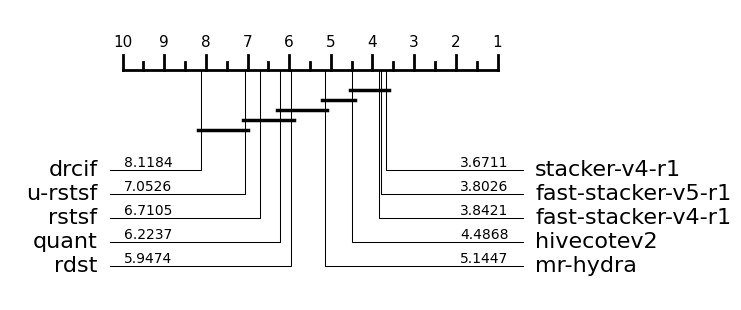

In [7]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [8]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [9]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,hivecotev2,drcif,u-rstsf,stacker-v4-r1,mr-hydra,fast-stacker-v5-r1,quant,rdst,rstsf,fast-stacker-v4-r1,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DodgerLoopWeekend""",0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""BeetleFly""",0.94,0.87,0.87,0.94,0.9,0.8,0.81,0.95,0.9,0.8,20,20,2,512
"""ShapeletSim""",1.0,0.92,0.963333,1.0,1.0,1.0,0.983333,1.0,0.968889,1.0,20,180,2,500
"""SonyAIBORobotSurface2""",0.922001,0.89255,0.913536,0.935992,0.941658,0.940189,0.848059,0.894229,0.882057,0.932844,27,953,2,65
"""FreezerSmallTrain""",0.999181,0.999088,0.965263,0.998386,0.994316,0.997895,0.998947,0.994877,0.996561,0.998596,28,2850,2,301
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ProximalPhalanxOutlineCorrect""",0.895189,0.893471,0.90378,0.921649,0.919588,0.931271,0.907904,0.886598,0.913402,0.931271,600,291,2,80
"""UWaveGestureLibraryX""",0.855202,0.815131,0.841039,0.875098,0.871245,0.875628,0.844556,0.855388,0.825349,0.874651,896,3582,8,315
"""StarLightCurves""",0.982273,0.979383,0.980282,0.982807,0.981666,0.98288,0.979845,0.98237,0.979699,0.982941,1000,8236,3,1024


24


(<Figure size 600x290 with 1 Axes>, <Axes: >)

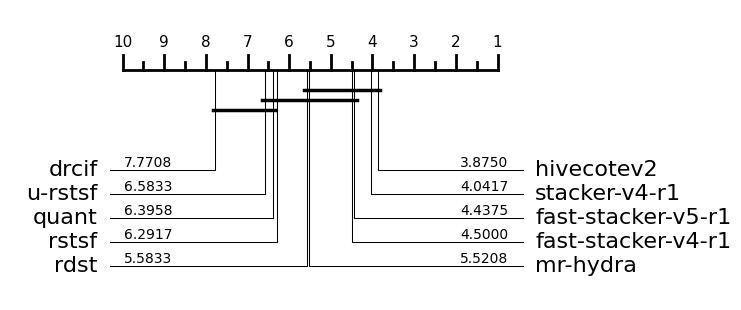

In [10]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

8


(<Figure size 600x290 with 1 Axes>, <Axes: >)

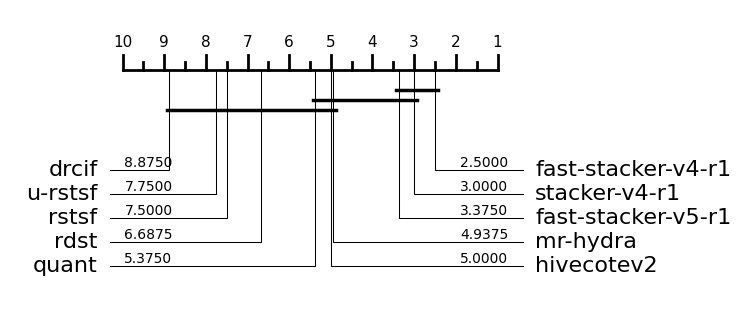

In [11]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

6


(<Figure size 600x290 with 1 Axes>, <Axes: >)

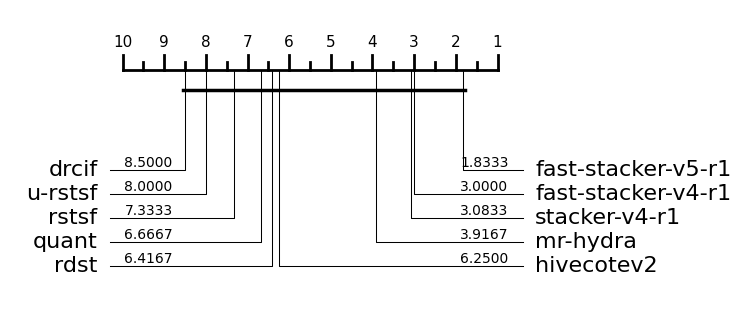

In [12]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [13]:
rdf.collect().pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).sort('downsample-mr-hydra')

dataset,polar-angle-mr-hydra,hivecotev2,downsample-mr-hydra,drcif,scale-mr-hydra,polar-magnitude-mr-hydra,catch22,u-rstsf,stacker-v4-r1,cumsum-mr-hydra,mr-hydra,rank-mr-hydra,fast-stacker-v5-r1,stacker-v4-r3,quant,fast-stacker-v5-r3,rdst,rstsf,difference-mr-hydra,fast-stacker-v4-r1
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Phoneme""",0.288502,0.392141,0.327954,0.356224,0.349895,0.354008,0.305802,0.38903,0.349895,0.269093,0.349895,0.34557,null,null,0.382278,null,0.337975,0.380907,0.369831,null
"""InlineSkate""",0.436727,0.533182,0.464364,0.502182,0.496727,0.497455,0.434182,0.623636,0.586545,0.431273,0.497091,0.469818,0.584545,null,0.586909,0.598182,0.447273,0.601818,0.475273,0.569091
"""ScreenType""",0.488533,0.561778,0.511467,0.529067,0.529067,0.5392,0.501867,0.5504,0.546133,0.48,0.5472,0.495467,null,null,0.5328,null,0.5216,0.522133,0.5344,0.557333
"""MiddlePhalanxOutlineAgeGroup""",0.527273,0.575325,0.515584,0.574026,0.580519,0.544156,0.6,0.603896,0.580519,0.579221,0.576623,0.579221,null,null,0.61039,null,0.584416,0.597403,0.535065,0.581169
"""RefrigerationDevices""",0.589333,0.552,0.521067,0.592533,0.528,0.524267,0.507733,0.5824,0.577067,0.506133,0.526933,0.5472,0.562667,null,0.581867,null,0.5568,0.5904,0.538667,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GunPointOldVersusYoung""",0.996825,1.0,1.0,1.0,0.996825,1.0,1.0,1.0,1.0,0.989841,1.0,0.979683,1.0,null,1.0,null,1.0,1.0,1.0,1.0
"""TwoPatterns""",0.99195,1.0,1.0,0.99425,1.0,0.30035,0.8436,0.992,1.0,0.9977,1.0,0.99975,1.0,1.0,0.99995,null,1.0,0.99645,0.9932,1.0
"""GunPointMaleVersusFemale""",0.996835,1.0,1.0,0.999367,1.0,1.0,0.990506,1.0,1.0,0.996835,1.0,0.982278,1.0,1.0,1.0,1.0,1.0,1.0,0.996835,1.0


In [14]:
import ray
ray.shutdown()